In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#load raw dataset
data = pd.read_csv("../data/raw/patient_readmission_raw.csv")

In [3]:
#confirm if  the dataset has loaded
data.head()

,Patient_ID,Age,Sex,Length_of_Stay,Previous_Admissions,Emergency_Visits,Chronic_Conditions,Number_of_Medications,Abnormal_Lab_Count,Previous_Readmission,Follow_Up_Completed,Insurance_Type,Discharge_Disposition,Readmitted_30_Days
0,P00001,69,Male,6,3,0,0,4,0,0,1,Uninsured,Home,0
1,P00002,32,Female,2,2,2,3,4,3,0,1,Private,Skilled_Nursing,0
2,P00003,89,Male,6,3,0,1,11,0,0,1,Private,Home,0
3,P00004,78,Male,5,2,2,1,3,0,1,1,Public,Home,0
4,P00005,38,Female,5,3,1,2,4,3,0,1,Public,Home_Health,0


In [4]:
#check the dimensions of our dataset (we now have 13 columns because we added readmsiion_30_days 
data.shape

(5000, 14)

In [5]:
#check columns
data.columns

Index(['Patient_ID', 'Age', 'Sex', 'Length_of_Stay', 'Previous_Admissions',
       'Emergency_Visits', 'Chronic_Conditions', 'Number_of_Medications',
       'Abnormal_Lab_Count', 'Previous_Readmission', 'Follow_Up_Completed',
       'Insurance_Type', 'Discharge_Disposition', 'Readmitted_30_Days'],
      dtype='object')

In [6]:
#Check more on the data(description)
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   Patient_ID             5000 non-null   object
 1   Age                    5000 non-null   int64 
 2   Sex                    5000 non-null   object
 3   Length_of_Stay         5000 non-null   int64 
 4   Previous_Admissions    5000 non-null   int64 
 5   Emergency_Visits       5000 non-null   int64 
 6   Chronic_Conditions     5000 non-null   int64 
 7   Number_of_Medications  5000 non-null   int64 
 8   Abnormal_Lab_Count     5000 non-null   int64 
 9   Previous_Readmission   5000 non-null   int64 
 10  Follow_Up_Completed    5000 non-null   int64 
 11  Insurance_Type         5000 non-null   object
 12  Discharge_Disposition  5000 non-null   object
 13  Readmitted_30_Days     5000 non-null   int64 
dtypes: int64(10), object(4)
memory usage: 547.0+ KB


In [7]:
#cehck missing values 
data.isnull().sum()

Patient_ID               0
Age                      0
Sex                      0
Length_of_Stay           0
Previous_Admissions      0
Emergency_Visits         0
Chronic_Conditions       0
Number_of_Medications    0
Abnormal_Lab_Count       0
Previous_Readmission     0
Follow_Up_Completed      0
Insurance_Type           0
Discharge_Disposition    0
Readmitted_30_Days       0
dtype: int64

In [8]:
#check duplicated
data.duplicated().sum()

np.int64(0)

In [9]:
#check if our identifier patient id is unique to all 5000 patients
data["Patient_ID"].nunique()

5000

In [10]:
#DESCRIPTIVE ANALYSIS
data.describe()

,Age,Length_of_Stay,Previous_Admissions,Emergency_Visits,Chronic_Conditions,Number_of_Medications,Abnormal_Lab_Count,Previous_Readmission,Follow_Up_Completed,Readmitted_30_Days
count,5000.00000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,53.78360,6.014200,1.488000,1.21300,2.007200,5.982400,1.492600,0.234600,0.698600,0.188800
std,20.91777,2.218599,1.224155,1.09246,1.420405,2.417118,1.221574,0.423791,0.458912,0.391389
min,18.00000,1.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,36.00000,4.000000,1.000000,0.00000,1.000000,4.000000,1.000000,0.000000,0.000000,0.000000
50%,54.00000,6.000000,1.000000,1.00000,2.000000,6.000000,1.000000,0.000000,1.000000,0.000000
75%,72.00000,7.000000,2.000000,2.00000,3.000000,8.000000,2.000000,0.000000,1.000000,0.000000
max,90.00000,16.000000,9.000000,8.00000,9.000000,21.000000,7.000000,1.000000,1.000000,1.000000


In [11]:
#FOR CATEGORICAL VARIABLES
data.describe(include="object")

,Patient_ID,Sex,Insurance_Type,Discharge_Disposition
count,5000,5000,5000,5000
unique,5000,2,3,4
top,P00001,Male,Public,Home
freq,1,2511,2746,2949


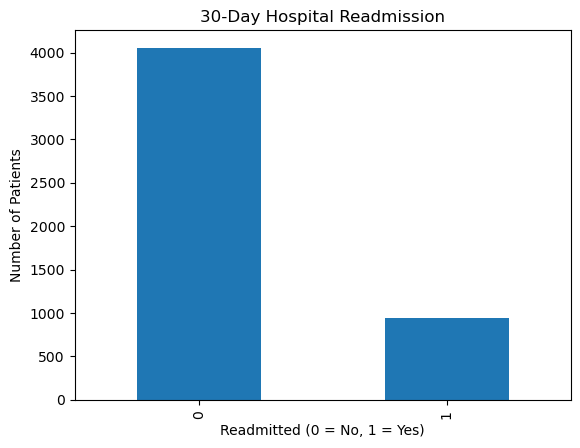

In [12]:
#EDA 
#Lets check the target distribution
data["Readmitted_30_Days"].value_counts().plot(kind="bar")

plt.title("30-Day Hospital Readmission")
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

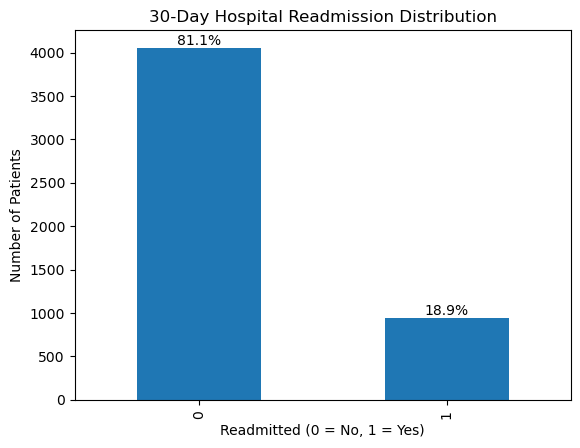

In [13]:
#Maybe we could make it a bit more informative
target_counts = data["Readmitted_30_Days"].value_counts()

target_counts.plot(kind="bar")

plt.title("30-Day Hospital Readmission Distribution")
plt.xlabel("Readmitted (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

for i, count in enumerate(target_counts):
    percentage = count / len(data) * 100
    plt.text(i, count, f"{percentage:.1f}%", ha="center", va="bottom")

plt.show()

In [14]:
#lets investigate AGE
data["Age"].describe()

count    5000.00000
mean       53.78360
std        20.91777
min        18.00000
25%        36.00000
50%        54.00000
75%        72.00000
max        90.00000
Name: Age, dtype: float64

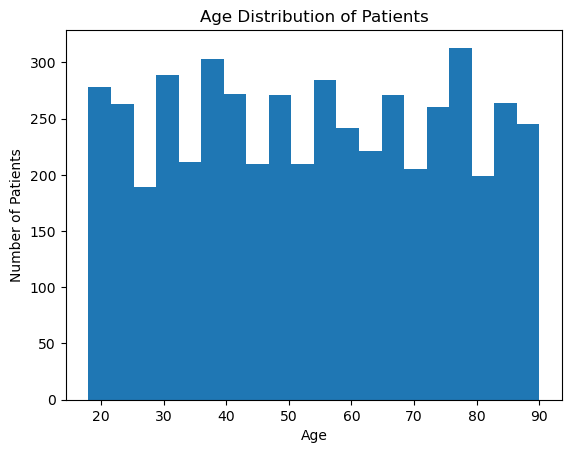

In [15]:
#plot a histogram for age...just to check if our data is plausible since its synthetic
data["Age"].plot(kind="hist", bins=20)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Number of Patients")

plt.show()

In [16]:
#check age range
data["Age"].min(), data["Age"].max()

(18, 90)

In [17]:
#check age mean and median...just to check if the distribution is symmetrical
data["Age"].mean(), data["Age"].median()

(np.float64(53.7836), 54.0)

# What can we see from this?
"""Age: The patient population ranges from 18 to 90 years, with a mean age of approximately 53.8 years and a median of 54 years. The histogram appears approximately bell-shaped, with the mean and median being very close, suggesting a relatively symmetric age distribution."""

In [18]:
#value counts for sex
data["Sex"].value_counts()

Sex
Male      2511
Female    2489
Name: count, dtype: int64

In [19]:
#%of the sex distribution
data["Sex"].value_counts(normalize=True) * 100

Sex
Male      50.22
Female    49.78
Name: proportion, dtype: float64

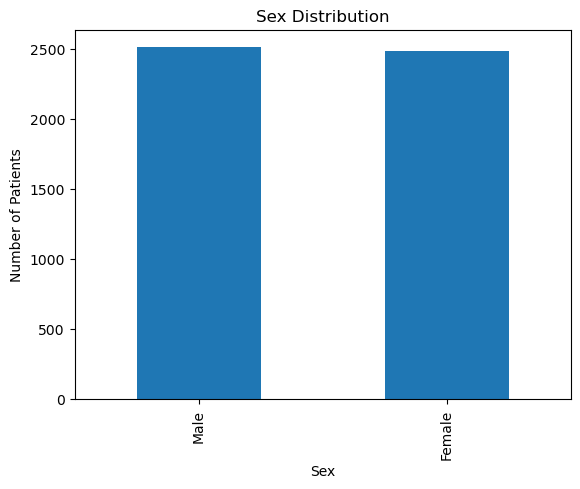

In [20]:
#visualise the sex distribution...its not imbalanced(closely***
data["Sex"].value_counts().plot(kind="bar")

plt.title("Sex Distribution")
plt.xlabel("Sex")
plt.ylabel("Number of Patients")

plt.show()

In [21]:
#UNIVARIATE EDA(Looking at realtionships between variables)
#we are using .mean() here because our target is binary 
data.groupby("Sex")["Readmitted_30_Days"].mean() * 100


Sex
Female    19.967859
Male      17.801673
Name: Readmitted_30_Days, dtype: float64

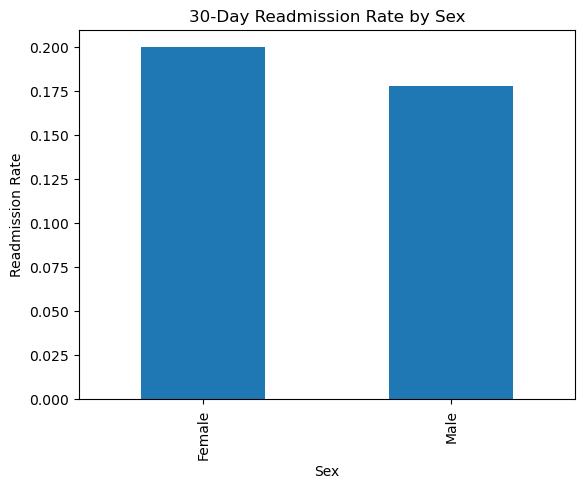

In [22]:
#we could visualise this
data.groupby("Sex")["Readmitted_30_Days"].mean().plot(kind="bar")

plt.title("30-Day Readmission Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Readmission Rate")

plt.show()

In [23]:
#lets look at the distribution for previous distributions
data["Previous_Admissions"].value_counts().sort_index()

Previous_Admissions
0    1119
1    1703
2    1248
3     608
4     224
5      74
6      19
7       4
9       1
Name: count, dtype: int64

In [24]:
#readmission rate a each level
data.groupby("Previous_Admissions")["Readmitted_30_Days"].mean() * 100

Previous_Admissions
0     14.745308
1     16.382854
2     20.753205
3     22.861842
4     28.125000
5     33.783784
6     52.631579
7     75.000000
9    100.000000
Name: Readmitted_30_Days, dtype: float64

# what did we find out from this realtionship?
"""As the number of previous admissions increases, the observed 30-day readmission rate generally increases.""

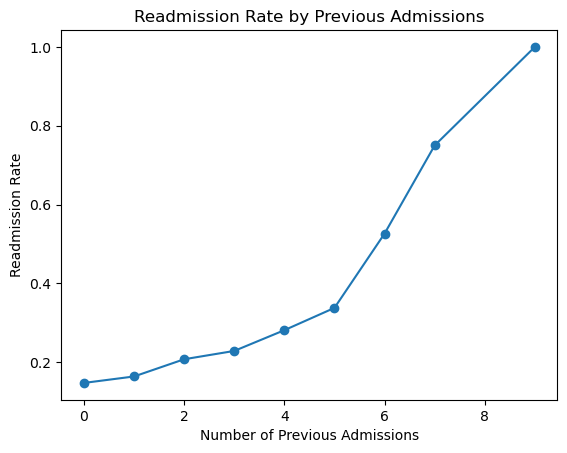

In [25]:
#lets visualise this relationship
data.groupby("Previous_Admissions")["Readmitted_30_Days"].mean().plot(
    kind="line",
    marker="o"
)

plt.title("Readmission Rate by Previous Admissions")
plt.xlabel("Number of Previous Admissions")
plt.ylabel("Readmission Rate")

plt.show()

# what can we see from the above relationship?
"""Previous Admissions: There is a generally increasing relationship between the number of previous admissions and the observed 30-day readmission rate. Patients with no previous admissions had a readmission rate of approximately 14.7%, compared with higher rates among patients with increasing numbers of previous admissions. However, estimates for categories with very small sample sizes should be interpreted cautiously."""

In [26]:
#check the distribution in emergency visits
data["Emergency_Visits"].value_counts().sort_index()

Emergency_Visits
0    1469
1    1822
2    1097
3     446
4     125
5      38
6       1
7       1
8       1
Name: count, dtype: int64

In [27]:
#calculate the readmission rate
data.groupby("Emergency_Visits")["Readmitted_30_Days"].mean() * 100

Emergency_Visits
0     16.473792
1     16.849616
2     20.601641
3     27.354260
4     29.600000
5     21.052632
6    100.000000
7    100.000000
8      0.000000
Name: Readmitted_30_Days, dtype: float64

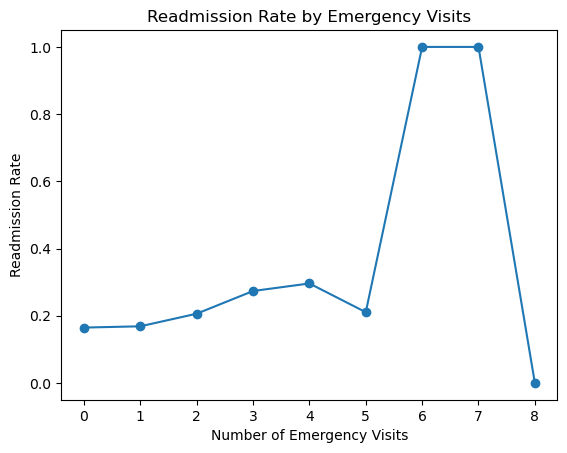

In [28]:
#visualise it
data.groupby("Emergency_Visits")["Readmitted_30_Days"].mean().plot(
    kind="line",
    marker="o"
)

plt.title("Readmission Rate by Emergency Visits")
plt.xlabel("Number of Emergency Visits")
plt.ylabel("Readmission Rate")

plt.show()

# what does this tell us 
Emergency Visits: Readmission rates generally increase with increasing emergency visits up to approximately four visits. Categories with very small sample sizes show substantial variability and should be interpreted cautiously. The observed pattern is broadly consistent with the positive contribution of emergency visits in the synthetic data-generating process. However, A percentage without its denominator can be misleading.

In [29]:
#lets check distribution of chronic conditions
data["Chronic_Conditions"].value_counts().sort_index()

Chronic_Conditions
0     660
1    1368
2    1350
3     921
4     429
5     177
6      69
7      21
8       2
9       3
Name: count, dtype: int64

In [30]:
#lets check the readmission rate
data.groupby("Chronic_Conditions")["Readmitted_30_Days"].mean() * 100

Chronic_Conditions
0    10.303030
1    14.473684
2    18.740741
3    22.366992
4    27.738928
5    36.158192
6    36.231884
7    42.857143
8     0.000000
9    66.666667
Name: Readmitted_30_Days, dtype: float64

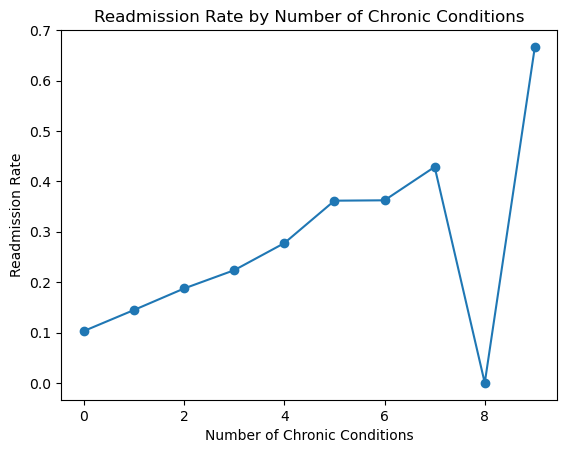

In [31]:
#lets visualise it
data.groupby("Chronic_Conditions")["Readmitted_30_Days"].mean().plot(
    kind="line",
    marker="o"
)

plt.title("Readmission Rate by Number of Chronic Conditions")
plt.xlabel("Number of Chronic Conditions")
plt.ylabel("Readmission Rate")

plt.show()

# what do we see from this relationship
Chronic Conditions: The observed 30-day readmission rate generally increases as the number of chronic conditions increases, with rates rising from 10.3% among patients with no chronic conditions to 42.9% among those with seven. Categories with very small sample sizes, particularly eight and nine chronic conditions, show unstable rates and should be interpreted cautiously.

In [32]:
#lets check length of stay
data["Length_of_Stay"].describe()

count    5000.000000
mean        6.014200
std         2.218599
min         1.000000
25%         4.000000
50%         6.000000
75%         7.000000
max        16.000000
Name: Length_of_Stay, dtype: float64

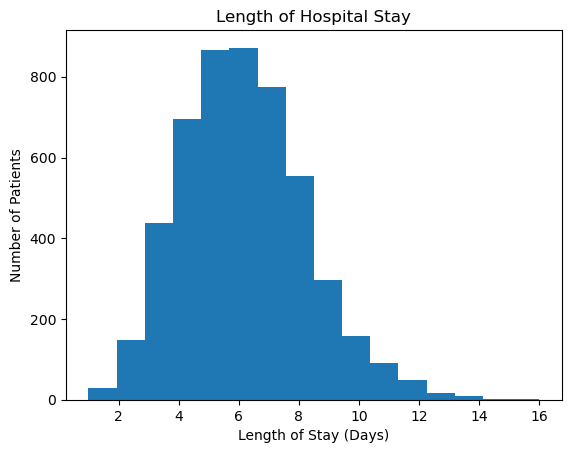

In [33]:
#lets visualise
data["Length_of_Stay"].plot(kind="hist", bins=16)

plt.title("Length of Hospital Stay")
plt.xlabel("Length of Stay (Days)")
plt.ylabel("Number of Patients")

plt.show()

In [34]:
#lets check the readmission rate
data.groupby("Length_of_Stay")["Readmitted_30_Days"].mean() * 100

Length_of_Stay
1       0.000000
2      11.564626
3      16.933638
4      15.660920
5      19.377163
6      19.380734
7      20.903226
8      21.518987
9      15.824916
10     25.157233
11     21.978022
12     14.583333
13     25.000000
14     50.000000
15     66.666667
16    100.000000
Name: Readmitted_30_Days, dtype: float64

# what does the above mean
Length of Stay: Readmission rates show a generally increasing tendency with longer hospital stays, although the relationship is not monotonic across every length-of-stay category. Higher rates among very long stays should be interpreted cautiously because these categories may contain relatively few patients. The observed pattern is broadly consistent with the positive contribution of length of stay in the synthetic data-generating process.

In [35]:
"""There's an overall tendency, but the relationship isn't perfectly monotonic and I need to consider sample size and other variables."""

"There's an overall tendency, but the relationship isn't perfectly monotonic and I need to consider sample size and other variables."

In [36]:
data.columns.tolist()

['Patient_ID',
 'Age',
 'Sex',
 'Length_of_Stay',
 'Previous_Admissions',
 'Emergency_Visits',
 'Chronic_Conditions',
 'Number_of_Medications',
 'Abnormal_Lab_Count',
 'Previous_Readmission',
 'Follow_Up_Completed',
 'Insurance_Type',
 'Discharge_Disposition',
 'Readmitted_30_Days']

In [37]:
#lets check medications
data["Number_of_Medications"].describe()

count    5000.000000
mean        5.982400
std         2.417118
min         0.000000
25%         4.000000
50%         6.000000
75%         8.000000
max        21.000000
Name: Number_of_Medications, dtype: float64

In [38]:
#lets check count
data["Number_of_Medications"].value_counts().sort_index()

Number_of_Medications
0       9
1      68
2     241
3     426
4     671
5     801
6     829
7     703
8     521
9     356
10    167
11    109
12     58
13     24
14     12
15      3
17      1
21      1
Name: count, dtype: int64

In [39]:
#group by(rating)
data.groupby("Number_of_Medications")["Readmitted_30_Days"].mean() * 100

Number_of_Medications
0      22.222222
1      16.176471
2      20.331950
3      18.075117
4      17.734724
5      19.975031
6      20.747889
7      18.918919
8      14.971209
9      18.820225
10     20.958084
11     16.513761
12     15.517241
13     29.166667
14     33.333333
15     66.666667
17    100.000000
21      0.000000
Name: Readmitted_30_Days, dtype: float64

# What do we get here
Number of Medications: Patients had an average of approximately six medications, with values ranging from 0 to 21. The observed readmission rates fluctuate across medication counts without a clear monotonic pattern. Estimates for medication counts above 14 should be interpreted cautiously because of very small sample sizes.

In [40]:
#we check abnoraml lab count
data["Abnormal_Lab_Count"].describe()

count    5000.000000
mean        1.492600
std         1.221574
min         0.000000
25%         1.000000
50%         1.000000
75%         2.000000
max         7.000000
Name: Abnormal_Lab_Count, dtype: float64

In [41]:
#count
data["Abnormal_Lab_Count"].value_counts().sort_index()

Abnormal_Lab_Count
0    1127
1    1666
2    1275
3     594
4     251
5      66
6      16
7       5
Name: count, dtype: int64

In [42]:
#rate
data.groupby("Abnormal_Lab_Count")["Readmitted_30_Days"].mean() * 100

Abnormal_Lab_Count
0    17.657498
1    18.607443
2    19.686275
3    18.855219
4    19.123506
5    31.818182
6    12.500000
7    20.000000
Name: Readmitted_30_Days, dtype: float64

# What does the above show?
Abnormal Lab Count: Patients had an average of approximately 1.5 abnormal laboratory results. Readmission rates were relatively stable across 0–4 abnormal results, with greater variability at higher counts. The variable does not demonstrate a strong monotonic relationship with 30-day readmission in the univariate analysis. Higher-count categories should be interpreted cautiously because of smaller sample sizes.

In [43]:
#check previous readmission distribution
data["Previous_Readmission"].value_counts()

Previous_Readmission
0    3827
1    1173
Name: count, dtype: int64

In [44]:
#%distribution
data["Previous_Readmission"].value_counts(normalize=True) * 100

Previous_Readmission
0    76.54
1    23.46
Name: proportion, dtype: float64

In [45]:
#check relationship
data.groupby("Previous_Readmission")["Readmitted_30_Days"].mean() * 100

Previous_Readmission
0    16.017768
1    28.218244
Name: Readmitted_30_Days, dtype: float64

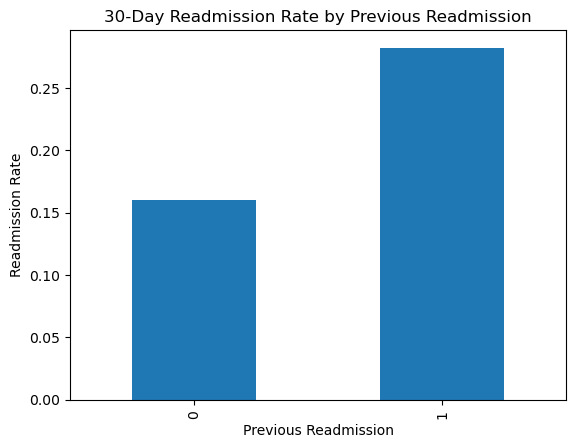

In [46]:
#visualise
data.groupby("Previous_Readmission")["Readmitted_30_Days"].mean().plot(
    kind="bar"
)

plt.title("30-Day Readmission Rate by Previous Readmission")
plt.xlabel("Previous Readmission")
plt.ylabel("Readmission Rate")

plt.show()

In [47]:
#lets understand follow_uo completed (distribution)
data["Follow_Up_Completed"].value_counts()

Follow_Up_Completed
1    3493
0    1507
Name: count, dtype: int64

In [48]:
data.groupby("Follow_Up_Completed")["Readmitted_30_Days"].mean() * 100

Follow_Up_Completed
0    23.092236
1    17.062697
Name: Readmitted_30_Days, dtype: float64

# now  what do we learn here
Patients who did not complete follow-up had a higher 30-day readmission rate (23.09%) compared with patients who completed follow-up (17.06%). This suggests that follow-up completion may be associated with lower readmission risk in the synthetic dataset.

In [49]:
#patients distribution across insurance types
data["Insurance_Type"].value_counts()

Insurance_Type
Public       2746
Private      1742
Uninsured     512
Name: count, dtype: int64

In [50]:
data["Insurance_Type"].value_counts(normalize=True) * 100

Insurance_Type
Public       54.92
Private      34.84
Uninsured    10.24
Name: proportion, dtype: float64

In [51]:
data.groupby("Insurance_Type")["Readmitted_30_Days"].mean() * 100

Insurance_Type
Private      18.484501
Public       19.118718
Uninsured    18.945312
Name: Readmitted_30_Days, dtype: float64

# Now what does this tell us
Insurance type showed little variation in 30-day readmission rates across categories. Public, uninsured, and private patients had similar readmission rates, suggesting a weak univariate relationship between insurance type and readmission.

In [52]:
# lets check discharge disposition and its distribution
data["Discharge_Disposition"].value_counts()

Discharge_Disposition
Home               2949
Home_Health        1039
Skilled_Nursing     741
Other               271
Name: count, dtype: int64

In [53]:
data["Discharge_Disposition"].value_counts(normalize=True) * 100

Discharge_Disposition
Home               58.98
Home_Health        20.78
Skilled_Nursing    14.82
Other               5.42
Name: proportion, dtype: float64

In [54]:
data.groupby("Discharge_Disposition")["Readmitted_30_Days"].mean() * 100

Discharge_Disposition
Home               18.582570
Home_Health        20.789220
Other              18.819188
Skilled_Nursing    17.408907
Name: Readmitted_30_Days, dtype: float64

# What does the above tell us?
Discharge disposition showed some variation in 30-day readmission rates. Patients discharged to home health had the highest readmission rate (20.79%), while those discharged to skilled nursing had the lowest (17.41%). Overall, the relationship appears weak to moderate, with relatively small differences across categories.

#                                PREPROCESSING

In [55]:
#step 1
#Define x and y
X = data.drop(columns=["Readmitted_30_Days", "Patient_ID", "Follow_Up_Completed"])
y = data["Readmitted_30_Days"]
"""So x contains the information we shall give to the model while y contains what we want the model to predict"""


'So x contains the information we shall give to the model while y contains what we want the model to predict'

In [56]:
#confirm the columns were dropped
X.shape

(5000, 11)

In [57]:
y.shape

(5000,)

In [58]:
X.columns

Index(['Age', 'Sex', 'Length_of_Stay', 'Previous_Admissions',
       'Emergency_Visits', 'Chronic_Conditions', 'Number_of_Medications',
       'Abnormal_Lab_Count', 'Previous_Readmission', 'Insurance_Type',
       'Discharge_Disposition'],
      dtype='object')

In [59]:
""" After dropping now we have 11 columns...So basically11 predictors → model → 30-day readmission"""


' After dropping now we have 11 columns...So basically11 predictors → model → 30-day readmission'

In [60]:
#step 2 preprocessing
#identify categorical vs numerical variables
X.dtypes

Age                       int64
Sex                      object
Length_of_Stay            int64
Previous_Admissions       int64
Emergency_Visits          int64
Chronic_Conditions        int64
Number_of_Medications     int64
Abnormal_Lab_Count        int64
Previous_Readmission      int64
Insurance_Type           object
Discharge_Disposition    object
dtype: object

In [61]:
""" now we have 8 numerical and 3 categorical which we need to thereafter encode """

' now we have 8 numerical and 3 categorical which we need to thereafter encode '

In [62]:
#step 3
# encoding
# first import the encoder
from sklearn.preprocessing import OneHotEncoder

In [63]:
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

In [64]:
""" handle_unknown="ignore"(This is useful later when our model encounters a category in the test/new data that wasn't present in the training data.

Instead of throwing an error, the encoder handles it safely.
And sparse_output=False tells sklearn to give us a regular pandas-friendly array rather than a sparse matrix."""

' handle_unknown="ignore"(This is useful later when our model encounters a category in the test/new data that wasn\'t present in the training data.\n\nInstead of throwing an error, the encoder handles it safely.\nAnd sparse_output=False tells sklearn to give us a regular pandas-friendly array rather than a sparse matrix.'

In [65]:
#lets encode them now
categorical_columns = ["Sex", "Insurance_Type", "Discharge_Disposition"]

encoded_data = encoder.fit_transform(X[categorical_columns])

In [66]:
#check if they were encoded 
encoder.get_feature_names_out(categorical_columns)

array(['Sex_Female', 'Sex_Male', 'Insurance_Type_Private',
       'Insurance_Type_Public', 'Insurance_Type_Uninsured',
       'Discharge_Disposition_Home', 'Discharge_Disposition_Home_Health',
       'Discharge_Disposition_Other',
       'Discharge_Disposition_Skilled_Nursing'], dtype=object)

In [67]:

# lets also take the encoded values and putting them into a proper DataFrame:
encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical_columns),
    index=X.index
)

In [68]:
#lets check if they were combined successfuly
encoded_df.head()

,Sex_Female,Sex_Male,Insurance_Type_Private,Insurance_Type_Public,Insurance_Type_Uninsured,Discharge_Disposition_Home,Discharge_Disposition_Home_Health,Discharge_Disposition_Other,Discharge_Disposition_Skilled_Nursing
0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0
1,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0


In [69]:
encoded_df.shape

(5000, 9)

In [70]:
#Step 4
#combine the encoded categorical features with our numerical features.
numerical_columns = [
    "Age",
    "Length_of_Stay",
    "Previous_Admissions",
    "Emergency_Visits",
    "Chronic_Conditions",
    "Number_of_Medications",
    "Abnormal_Lab_Count",
    "Previous_Readmission"
]

In [71]:
numerical_data = X[numerical_columns]

In [72]:
X_processed = pd.concat([numerical_data, encoded_df], axis=1)

In [73]:
#check if they were combined
X_processed.shape

(5000, 17)

# Train - Test Split
"""We need to divide our 5,000 patients into:

 -Training data → model learns patterns
 -Testing data → model is evaluated on unseen patients

And because our target is somewhat imbalanced (~18–19% readmitted), we'll need to use stratification so the train and test sets maintain roughly the same class proportions."""

In [74]:
#Step 5 — Train/Test Split
from sklearn.model_selection import train_test_split

In [75]:
"""And because our target is imbalanced, we'll use stratify=y."""

"And because our target is imbalanced, we'll use stratify=y."

In [76]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)
""" what the parameters mean is that: test_size=0.20
→ 20% goes to testing.

random_state=42
→ makes the split reproducible. If we run it again, we get the same split.

stratify=y ⭐
→ maintains approximately the same proportion of readmitted/non-readmitted patients in both training and testing sets."""

' what the parameters mean is that: test_size=0.20\n→ 20% goes to testing.\n\nrandom_state=42\n→ makes the split reproducible. If we run it again, we get the same split.\n\nstratify=y ⭐\n→ maintains approximately the same proportion of readmitted/non-readmitted patients in both training and testing sets.'

In [77]:
#check the shapes
X_train.shape, X_test.shape, y_train.shape, y_test.shape
"""Why we did this is because the model will learn only from the 4,000 training patients.
The 1,000 test patients are kept aside until we're ready to evaluate the model. This gives us a more honest estimate of how it performs on unseen patients."""

"Why we did this is because the model will learn only from the 4,000 training patients.\nThe 1,000 test patients are kept aside until we're ready to evaluate the model. This gives us a more honest estimate of how it performs on unseen patients."

In [78]:
""" since we used stratify=y then we preserved the readmission proportion in both sets."""
""" Now Why this matters,if we had split without stratification, we could accidentally end up with noticeably different class proportions between training and testing. That could make our evaluation less representative."""
#lets verify
y_train.value_counts(normalize=True) * 100

Readmitted_30_Days
0    81.125
1    18.875
Name: proportion, dtype: float64

In [79]:
#lets verify
y_test.value_counts(normalize=True) * 100

Readmitted_30_Days
0    81.1
1    18.9
Name: proportion, dtype: float64

In [80]:
#step 6
#scaling
"""we shall use standardscaler but we only fit the scaler on x_train then transform both xtrain and x_test"""
#import the scaler
from sklearn.preprocessing import StandardScaler
#create the scaler
scaler = StandardScaler()

In [81]:
#fit it only on the training data and transform the training data(use fit transform here)
X_train_scaled = scaler.fit_transform(X_train)

In [82]:
#transform the test data using the same fitted scaler(use transform here)
"""We never do fit_transform() on the test set because that would allow information from the test set to influence the preprocessing."""
X_test_scaled = scaler.transform(X_test)

In [83]:
#lets confirm 
X_train_scaled.shape, X_test_scaled.shape

((4000, 17), (1000, 17))

In [84]:
#let's verify that the scaling actually happened
X_train_scaled.mean(axis=0)

array([-9.76996262e-17, -3.37507799e-17, -2.22044605e-17,  5.19584376e-17,
       -1.31450406e-16,  1.75859327e-16,  6.97220059e-17, -6.83897383e-17,
       -1.62536651e-16,  1.62536651e-16, -5.68434189e-17, -6.92779167e-17,
        3.90798505e-17,  8.34887715e-17,  2.79776202e-17, -1.06581410e-17,
        7.10542736e-18])

In [85]:
#lets continue to verify
X_train_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.])

# MODEL DEVELOPMENT

In [86]:
#Step 1 — Logistic Regression Baseline
#import the model
from sklearn.linear_model import LogisticRegression

In [87]:
#create the model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)
"""we are using max_iter=1000 because the model uses an iterative optimization process to find its coefficients. 1000 gives it plenty of iterations to converge rather than stopping too early."""

'we are using max_iter=1000 because the model uses an iterative optimization process to find its coefficients. 1000 gives it plenty of iterations to converge rather than stopping too early.'

In [88]:
#train the model(here we use our scaled training data)
logistic_model.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [89]:
#step 2
#make predictions(to see how the model behaves on unseen data
y_pred = logistic_model.predict(X_test_scaled)


In [90]:
#check how many predictions of each class it made
pd.Series(y_pred).value_counts()

0    994
1      6
Name: count, dtype: int64

In [91]:
"""Our model predicted:
0 → 994 patients
1 → 6 patients
But remember our actual test set contains about:
811 not readmitted
189 readmitted
So the model is predicting almost everyone as not readmitted. 
Why this matters-If we only looked at accuracy, this model could look deceptively good because most patients are in class 0.
But it is barely identifying the patients we actually care about: those at risk of readmission"""

'Our model predicted:\n0 → 994 patients\n1 → 6 patients\nBut remember our actual test set contains about:\n811 not readmitted\n189 readmitted\nSo the model is predicting almost everyone as not readmitted. \nWhy this matters-If we only looked at accuracy, this model could look deceptively good because most patients are in class 0.\nBut it is barely identifying the patients we actually care about: those at risk of readmission'

In [92]:
#lets see how well it performed using confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

cm

array([[808,   3],
       [186,   3]])

In [93]:
"""The model For our project:
TN = 808 
FP = 3
FN = 186 
TP = 3 
The confusion matrix itself doesn't give us a single "score." Instead, it gives us the building blocks for metrics such as:
Accuracy → how many predictions were correct overall
Precision → when the model predicts readmission, how often is it right?
Recall (Sensitivity) → of the patients who actually were readmitted, how many did we catch?
F1-score → balances precision and recall
For a healthcare readmission model, recall is particularly important to examine, because missing a genuinely high-risk patient can be more concerning than generating a few false alarms."""

'The model For our project:\nTN = 808 \nFP = 3\nFN = 186 \nTP = 3 \nThe confusion matrix itself doesn\'t give us a single "score." Instead, it gives us the building blocks for metrics such as:\nAccuracy → how many predictions were correct overall\nPrecision → when the model predicts readmission, how often is it right?\nRecall (Sensitivity) → of the patients who actually were readmitted, how many did we catch?\nF1-score → balances precision and recall\nFor a healthcare readmission model, recall is particularly important to examine, because missing a genuinely high-risk patient can be more concerning than generating a few false alarms.'

In [94]:
#Let's calculate the first metric: accuracy.
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
accuracy
"""Is the model actually learning to identify readmissions, or is the 81.1% accuracy mostly coming from predicting the majority class? I think it is suggesting the latter"""

'Is the model actually learning to identify readmissions, or is the 81.1% accuracy mostly coming from predicting the majority class? I think it is suggesting the latter'

In [95]:
#lets check another metric Recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, y_pred)
recall


0.015873015873015872

In [96]:
"""The model detected only about 1.6% of the patients who were actually readmitted.

That means it missed about 98.4% of actual readmissions. 🚨

Why this is a serious problem for our project
***Imagine this were a real clinical decision-support system. A model that misses almost all patients who go on to be readmitted would be of very limited usefulness for identifying high-risk patients, even though its accuracy is 81.1%.
This is the perfect demonstration of why:
Accuracy ≠ good model performance, especially with an imbalanced target."""

'The model detected only about 1.6% of the patients who were actually readmitted.\n\nThat means it missed about 98.4% of actual readmissions. 🚨\n\nWhy this is a serious problem for our project\n***Imagine this were a real clinical decision-support system. A model that misses almost all patients who go on to be readmitted would be of very limited usefulness for identifying high-risk patients, even though its accuracy is 81.1%.\nThis is the perfect demonstration of why:\nAccuracy ≠ good model performance, especially with an imbalanced target.'

In [97]:
#lets look at precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, y_pred)
precision

0.5

In [98]:
"""When our model predicts readmission, it is correct half of the time. 3 true positives and 3 false positives...makes it 50%.
Our model has reasonable precision when it actually predicts a readmission, but it almost never makes that prediction.And that is why our recall is terrible and For our healthcare problem, missing 186 actual readmissions is a major concern."""

'When our model predicts readmission, it is correct half of the time. 3 true positives and 3 false positives...makes it 50%.\nOur model has reasonable precision when it actually predicts a readmission, but it almost never makes that prediction.And that is why our recall is terrible and For our healthcare problem, missing 186 actual readmissions is a major concern.'

In [99]:
#calculate F1-score, which combines precision and recall into one metric.
from sklearn.metrics import f1_score

f1 = f1_score(y_test, y_pred)
f1

0.03076923076923077

In [100]:
"""The problem is that although precision isn't terrible, recall is extremely low. Since F1 considers both, that tiny recall pulls the F1-score way down."""

"The problem is that although precision isn't terrible, recall is extremely low. Since F1 considers both, that tiny recall pulls the F1-score way down."

# Baseline Logistic Regression Results
The baseline Logistic Regression model achieved 81.1% accuracy, but performance on the positive class was poor. Precision was 50.0%, while recall was only 1.59%, resulting in an F1-score of 3.08%. The model correctly identified only 3 of the 189 patients who were readmitted within 30 days. This demonstrates that accuracy alone is insufficient for evaluating an imbalanced classification problem

In [101]:
#lets do class weighing (tell Logistic Regression to give more importance to the minority class.)
"""Without class weighting:

Mistake on class 0 → normal penalty
Mistake on class 1 → normal penalty


With class weighting:

Mistake on class 0 → lower relative penalty
Mistake on class 1 → higher relative penalty
So the model becomes more willing to classify a patient as 1 when the evidence supports it.
So we can use class weight= balance to automatically adjusts the weights based on the class frequencies.

We're not going to change our test data.

Our test set remains untouched.

We're simply going to train a second Logistic Regression model that is more sensitive to the minority class.

That gives us a very useful comparison:"""

"Without class weighting:\n\nMistake on class 0 → normal penalty\nMistake on class 1 → normal penalty\n\n\nWith class weighting:\n\nMistake on class 0 → lower relative penalty\nMistake on class 1 → higher relative penalty\nSo the model becomes more willing to classify a patient as 1 when the evidence supports it.\nSo we can use class weight= balance to automatically adjusts the weights based on the class frequencies.\n\nWe're not going to change our test data.\n\nOur test set remains untouched.\n\nWe're simply going to train a second Logistic Regression model that is more sensitive to the minority class.\n\nThat gives us a very useful comparison:"

In [102]:
#step 1
#Now lets create the second model//////class-weighted logistic regression model
logistic_balanced = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

In [103]:
#train it 
logistic_balanced.fit(X_train_scaled, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [104]:
#step 2
#predict with the balanced model
y_pred_balanced = logistic_balanced.predict(X_test_scaled)

In [105]:
#count how many models the first model classifies as 0 and 1
pd.Series(y_pred_balanced).value_counts()

0    616
1    384
Name: count, dtype: int64

In [106]:
#lets calculate the new confusion matrix
cm_balanced = confusion_matrix(y_test, y_pred_balanced)

cm_balanced

array([[545, 266],
       [ 71, 118]])

In [107]:
#lets check the metrics..accuracy
accuracy_balanced = accuracy_score(y_test, y_pred_balanced)

In [108]:
#lets check precision
precision_balanced = precision_score(y_test, y_pred_balanced)


In [109]:
recall_balanced = recall_score(y_test, y_pred_balanced)


In [110]:
f1_balanced = f1_score(y_test, y_pred_balanced)


In [111]:
accuracy_balanced, precision_balanced, recall_balanced, f1_balanced

(0.663, 0.3072916666666667, 0.6243386243386243, 0.4118673647469459)

# What does this mean so far?
Class weighting substantially improved the model's ability to identify the minority class. Recall increased from 1.59% to 62.43%, while F1-score increased from 3.08% to 41.19%. However, this improvement came with reduced accuracy and precision and a substantial increase in false positives. This illustrates the precision–recall trade-off in imbalanced classification.

In [112]:
#lets have a classification report
"""Instead of looking at precision, recall, and F1 separately, the report gives us all three for each class:

Class 0 → not readmitted
Class 1 → readmitted

It also gives:

support → how many actual patients belong to each class
accuracy
macro average
weighted average

The most important section for our healthcare question will be class 1, because that's the readmission group we're trying to identify."""
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_balanced))

              precision    recall  f1-score   support

           0       0.88      0.67      0.76       811
           1       0.31      0.62      0.41       189

    accuracy                           0.66      1000
   macro avg       0.60      0.65      0.59      1000
weighted avg       0.78      0.66      0.70      1000



# what does this report mean?
The classification report confirmed that class weighting substantially improved detection of 30-day readmissions. The balanced Logistic Regression model achieved 62.4% recall for the readmitted class compared with 1.59% for the baseline model. However, precision for the readmitted class was 30.7%, indicating that the model generated a relatively high number of false positives. This reflects the trade-off between detecting more true readmissions and avoiding false alarms.

# Step: ROC-AUC
Can the model generally distinguish patients who will be readmitted from those who won't, across different probability thresholds?

In [113]:
#Step 1-Get the predicted probabilities
"""this gives the probability for both classes. y_proba contains the model's estimated readmission probability for every patient."""
y_proba = logistic_balanced.predict_proba(X_test_scaled)[:, 1]

In [114]:
y_proba[:10]

array([0.4570255 , 0.4136026 , 0.58034891, 0.50019316, 0.38058073,
       0.50587441, 0.66117564, 0.30394332, 0.29332266, 0.24541634])

In [115]:
#Now let's calculate ROC-AUC
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_proba)
roc_auc

0.6953072501777803

In [ ]:
"""ROC-AUC ranges from:
0.50 → essentially random guessing
0.60–0.70 → some discriminatory ability
0.70–0.80 → generally considered a reasonable/good level of discrimination
1.00 → perfect discrimination

So our model at 0.6953 has meaningful but modest discriminatory ability.
The model has some ability to rank patients who will be readmitted higher than patients who won't, but it is far from perfect.

And remember, this is synthetic data, so we're evaluating our ML workflow rather than claiming clinical performance.
The Logistic Regression model demonstrates fair/modest discriminatory performance, with a ROC-AUC of 0.695. It can distinguish between patients who are and are not readmitted better than random chance, but its discrimination is not yet strong.

And there's an important distinction:

ROC-AUC = 0.695 doesn't mean the model is 69.5% accurate.
It tells us about the model's ability to separate/rank higher-risk patients from lower-risk patients across different thresholds."""

# Threshold analysis

In [116]:
#Step 1 — Let's test a few thresholds(to see the trade-offs)
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.3 | Precision: 0.20 | Recall: 0.94 | F1: 0.34
Threshold: 0.4 | Precision: 0.24 | Recall: 0.81 | F1: 0.38
Threshold: 0.5 | Precision: 0.31 | Recall: 0.62 | F1: 0.41
Threshold: 0.6 | Precision: 0.39 | Recall: 0.41 | F1: 0.40
Threshold: 0.7 | Precision: 0.49 | Recall: 0.18 | F1: 0.26


# Random Forests Model

In [117]:
from sklearn.ensemble import RandomForestClassifier

In [119]:
#Step 2 — Build the Random Forest
"""n_estimators=200 → the forest will contain 200 decision trees.
class_weight="balanced" → gives more importance to the minority class (readmitted patients).
random_state=42 → makes our results reproducible."""
random_forest = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=42
)


In [120]:
#Step 3 — Train it
random_forest.fit(X_train_scaled, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [121]:
#Step 4 — Make predictions
y_pred_rf = random_forest.predict(X_test_scaled)

In [122]:
pd.Series(y_pred_rf).value_counts()

0    990
1     10
Name: count, dtype: int64

In [ ]:
"""Interesting!!We're using the default classification threshold of 0.5, just like before. The forest may be producing probabilities that are mostly below 0.5, even for patients who have some risk."""

In [123]:
#Step 5 — Let's see its confusion matrix
"""TN = 805 → correctly identified 805 patients who weren't readmitted.
FP = 6 → 6 patients were predicted as readmitted but weren't.
FN = 185 → 185 actual readmissions were missed. 🚨
TP = 4 → only 4 actual readmissions were correctly identified."""
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_rf

array([[805,   6],
       [185,   4]])

In [124]:
#lets calculate teh actual metrics
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

accuracy_rf, precision_rf, recall_rf, f1_rf

(0.809, 0.4, 0.021164021164021163, 0.04020100502512563)

In [125]:
#get random forest's probabilities
y_proba_rf = random_forest.predict_proba(X_test_scaled)[:, 1]

In [126]:
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
roc_auc_rf

0.6624358196491366

In [127]:
#Threshold analysis for Random Forest.
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred_threshold_rf = (y_proba_rf >= threshold).astype(int)
    
    precision = precision_score(y_test, y_pred_threshold_rf)
    recall = recall_score(y_test, y_pred_threshold_rf)
    f1 = f1_score(y_test, y_pred_threshold_rf)
    
    print(
        f"Threshold: {threshold} | "
        f"Precision: {precision:.2f} | "
        f"Recall: {recall:.2f} | "
        f"F1: {f1:.2f}"
    )

Threshold: 0.3 | Precision: 0.36 | Recall: 0.30 | F1: 0.33
Threshold: 0.4 | Precision: 0.37 | Recall: 0.09 | F1: 0.14
Threshold: 0.5 | Precision: 0.40 | Recall: 0.02 | F1: 0.04
Threshold: 0.6 | Precision: 0.00 | Recall: 0.00 | F1: 0.00
Threshold: 0.7 | Precision: 0.00 | Recall: 0.00 | F1: 0.00


C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\USER\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# now we want to understand what the Logistic Regression model learned

In [128]:
#Step 1 — Look at the coefficients
"""The coefficient tells us the direction and strength of the model's association with the predicted class.

Positive coefficient → pushes the prediction toward readmission (1)
Negative coefficient → pushes the prediction toward not readmitted (0)
Larger absolute value → stronger contribution, all else equal."""
coefficients = logistic_balanced.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": X_processed.columns,
    "Coefficient": coefficients
})

feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,Chronic_Conditions,0.387086
7,Previous_Readmission,0.305814
2,Previous_Admissions,0.303610
3,Emergency_Visits,0.225398
1,Length_of_Stay,0.160644
14,Discharge_Disposition_Home_Health,0.045861
8,Sex_Female,0.045654
6,Abnormal_Lab_Count,0.034487
12,Insurance_Type_Uninsured,0.020692
15,Discharge_Disposition_Other,0.018146


# compare the models systematically and decide which model is currently preferable for our objective.
Why are we doing this?Why are we doing this?

Because now we can stop looking at each model separately and ask:

Which model better serves our actual objective?

And remember our objective isn't simply maximum accuracy.

We're trying to identify patients at risk of 30-day readmission, so recall matters substantially because missing an actual readmission is important.

In [129]:
#Step 1 — Put our model results side by side
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy_balanced, accuracy_rf],
    "Precision": [precision_balanced, precision_rf],
    "Recall": [recall_balanced, recall_rf],
    "F1": [f1_balanced, f1_rf],
    "ROC_AUC": [roc_auc, roc_auc_rf]
})

model_comparison

,Model,Accuracy,Precision,Recall,F1,ROC_AUC
0,Logistic Regression,0.663,0.307292,0.624339,0.411867,0.695307
1,Random Forest,0.809,0.400000,0.021164,0.040201,0.662436


In [ ]:
"""Logistic Regression was selected as the preferred model because it demonstrated stronger recall, F1-score, and ROC-AUC than Random Forest, making it more suitable for identifying patients at risk of 30-day readmission. Although Random Forest achieved higher accuracy and precision, its very low recall resulted in substantially more missed readmissions."""

# Final clean up
We fitted the OneHotEncoder before splitting the data:Technically, the encoder saw the entire dataset before the train/test split. It is a small form of data leakage.

We should fix that properly before we save our final model. This is actually a great opportunity to learn the Pipeline + ColumnTransformer workflow—the professional way to combine preprocessing and modeling.

In [130]:
#Step 1 — Understand the two tools
#Step 2 — Import them
"""The big advantage is that the preprocessing is learned only from the training data when we fit the pipeline. That prevents the leakage we identified."""
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [131]:
#Step 2 — Define our numerical and categorical columns
numerical_columns = [
    "Age",
    "Length_of_Stay",
    "Previous_Admissions",
    "Emergency_Visits",
    "Chronic_Conditions",
    "Number_of_Medications",
    "Abnormal_Lab_Count",
    "Previous_Readmission"
]

categorical_columns = [
    "Sex",
    "Insurance_Type",
    "Discharge_Disposition"
]

In [132]:
#Step 3 — Build the ColumnTransformer
"""handle_unknown="ignore"

means that if a category appears in the test data that wasn't present in the training data, the encoder won't crash."""
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [135]:
#Step 4 — Connect preprocessing + Logistic Regression
final_logistic = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=1000
        ))
    ]
)

In [137]:
#Step 5 — Train the leakage-safe model
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [138]:
#lets verify
X_train_raw.shape, X_test_raw.shape

((4000, 11), (1000, 11))

In [139]:
#Step 6 — Train our clean pipeline
final_logistic.fit(X_train_raw, y_train_raw)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [140]:
#Step 7 — Make predictions with the final pipeline
y_pred_final = final_logistic.predict(X_test_raw)

In [141]:
pd.Series(y_pred_final).value_counts()

0    618
1    382
Name: count, dtype: int64

In [142]:
#Now let's evaluate this proper final model
"""This wil give us the metrics from the leakage-safe pipeline, which are the ones we should ultimately report."""
accuracy_final = accuracy_score(y_test_raw, y_pred_final)
precision_final = precision_score(y_test_raw, y_pred_final)
recall_final = recall_score(y_test_raw, y_pred_final)
f1_final = f1_score(y_test_raw, y_pred_final)

accuracy_final, precision_final, recall_final, f1_final

(0.663, 0.306282722513089, 0.6190476190476191, 0.4098073555166375)

In [143]:
#Let's calculate the ROC-AUC for this final pipeline.
y_proba_final = final_logistic.predict_proba(X_test_raw)[:, 1]

In [144]:
roc_auc_final = roc_auc_score(y_test_raw, y_proba_final)
roc_auc_final

0.6954116349923994

# final-model coefficients

In [145]:
#Step 1 — Extract the feature names from our pipeline
feature_names = final_logistic.named_steps["preprocessor"].get_feature_names_out()

In [146]:
feature_names

array(['num__Age', 'num__Length_of_Stay', 'num__Previous_Admissions',
       'num__Emergency_Visits', 'num__Chronic_Conditions',
       'num__Number_of_Medications', 'num__Abnormal_Lab_Count',
       'num__Previous_Readmission', 'cat__Sex_Female', 'cat__Sex_Male',
       'cat__Insurance_Type_Private', 'cat__Insurance_Type_Public',
       'cat__Insurance_Type_Uninsured', 'cat__Discharge_Disposition_Home',
       'cat__Discharge_Disposition_Home_Health',
       'cat__Discharge_Disposition_Other',
       'cat__Discharge_Disposition_Skilled_Nursing'], dtype=object)

In [147]:
#Step 2 — Extract the final coefficients
final_coefficients = final_logistic.named_steps["model"].coef_[0]


In [148]:
#create the table
final_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": final_coefficients
})

final_feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
4,num__Chronic_Conditions,0.386687
7,num__Previous_Readmission,0.305594
2,num__Previous_Admissions,0.303172
3,num__Emergency_Visits,0.225103
1,num__Length_of_Stay,0.160491
14,cat__Discharge_Disposition_Home_Health,0.091063
8,cat__Sex_Female,0.071313
15,cat__Discharge_Disposition_Other,0.056985
12,cat__Insurance_Type_Uninsured,0.040608
6,num__Abnormal_Lab_Count,0.034369


In [149]:
#final evaluation artifact: the confusion matrix for the final pipeline 
"""so our final model has a clean, final set of TN/FP/FN/TP values."""
final_cm = confusion_matrix(y_test_raw, y_pred_final)
final_cm

array([[546, 265],
       [ 72, 117]])

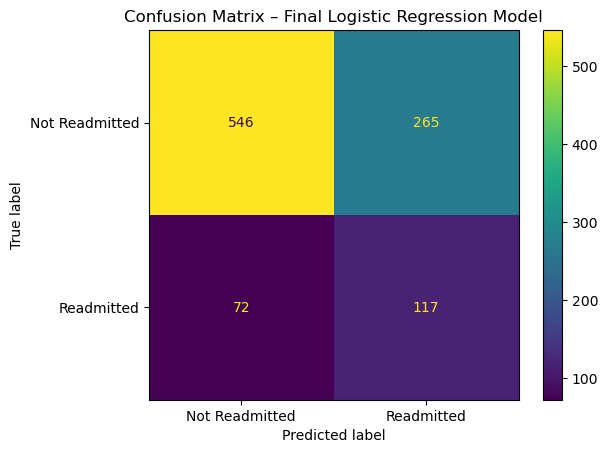

In [150]:
#visualizing the confusion matrix
#Step 1 — Create the confusion matrix visualization
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(
    y_test_raw,
    y_pred_final,
    display_labels=["Not Readmitted", "Readmitted"]
)

plt.title("Confusion Matrix – Final Logistic Regression Model")
plt.show()

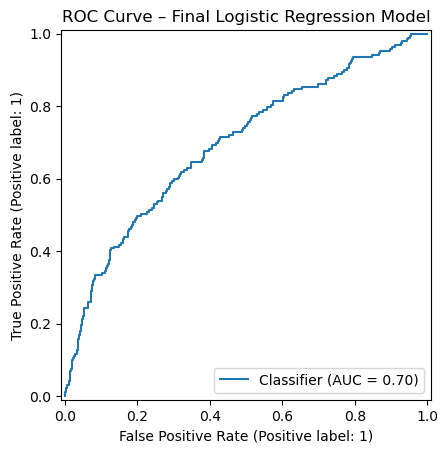

In [151]:
#Step 2 — Plot the ROC curve

from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(
    y_test_raw,
    y_proba_final
)

plt.title("ROC Curve – Final Logistic Regression Model")
plt.show()

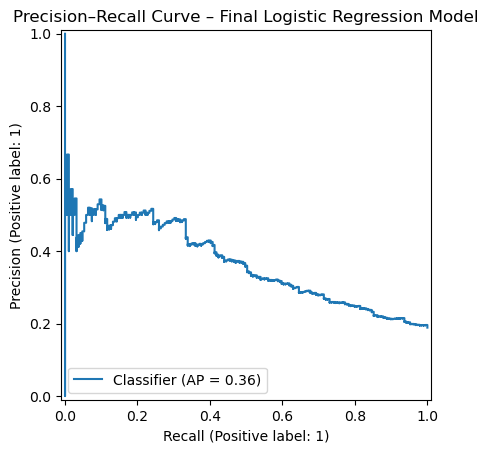

In [152]:
#Step 3 — Precision–Recall curve

from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(
    y_test_raw,
    y_proba_final
)

plt.title("Precision–Recall Curve – Final Logistic Regression Model")
plt.show()

# Save our final model

In [153]:
#step 1
import joblib

joblib.dump(
    final_logistic,
    "../models/final_logistic_pipeline.joblib"
)

['../models/final_logistic_pipeline.joblib']

In [154]:
#verify 
import os

os.path.exists("../models/final_logistic_pipeline.joblib")

True


# Patient 30-Day Readmission Prediction

## Project Overview
This project develops a machine learning model to predict whether a patient is likely to be readmitted to the hospital within 30 days of discharge.

The project uses a synthetic dataset of 5,000 patient records and follows an end-to-end machine learning workflow, including data understanding, exploratory data analysis, preprocessing, model training, evaluation, interpretation and prediction on new patient data.

The prediction point was defined as **at discharge**. Therefore, only information available at discharge was used as model input. Variables that would only become available after discharge, such as follow-up completion, were excluded to avoid data leakage.

Logistic Regression and Random Forest models were evaluated. The final leakage-safe Logistic Regression pipeline achieved a recall of approximately **61.9%** and a ROC-AUC of approximately **0.695** on the test set.

This project is for educational and demonstration purposes. The dataset is synthetic and the model has not been clinically validated or designed for real-world clinical decision-making.

## Dataset

The dataset contains **5,000 synthetic patient records** designed for this machine learning demonstration.

Each record represents a patient and contains demographic, utilization, clinical and discharge-related variables.

The target variable is:

- **Readmitted_30_Days** — indicates whether the patient was readmitted within 30 days of discharge.
  - `0` = Not readmitted
  - `1` = Readmitted

The model uses information available at the point of discharge. `Patient_ID` was excluded because it is an identifier, while `Follow_Up_Completed` was excluded because it represents information occurring after discharge and could introduce data leakage.

The dataset is synthetic and was created for educational purposes. It does not represent real patient records or real-world hospital readmission rates.

## Key Exploratory Data Analysis Findings

The target variable was imbalanced, with approximately **81% of patients not readmitted** and **19% readmitted within 30 days**. This indicated that accuracy alone would not be sufficient for evaluating the model.

Several variables showed a positive relationship with the readmission outcome:

- **Previous admissions:** Readmission rates generally increased as the number of previous admissions increased.
- **Emergency visits:** Higher numbers of emergency visits generally corresponded with higher readmission rates, although the smallest groups showed considerable variation.
- **Chronic conditions:** Patients with more chronic conditions generally had higher readmission rates.
- **Previous readmission:** Previous readmission was associated with a higher likelihood of subsequent readmission.
- **Length of stay:** Readmission rates showed a generally increasing pattern with longer hospital stays, although the relationship was not perfectly monotonic.

Other variables showed weaker or less consistent relationships with the target:

- **Age** showed no strong linear pattern.
- **Number of medications** did not show a clear monotonic relationship.
- **Insurance type** showed relatively small differences in readmission rates.
- **Sex** showed a small difference in observed readmission rates.
- **Discharge disposition** showed some differences between categories, but the overall differences were modest.

These findings helped guide the subsequent feature selection and model interpretation. However, the observed relationships are associations within a synthetic dataset and should not be interpreted as causal relationships.

## Feature Selection and Data Leakage

The prediction point for this project was defined as **the time of patient discharge**.

Therefore, the model was restricted to variables that would be available at or before discharge.

### Features used

- Age
- Sex
- Length_of_Stay
- Previous_Admissions
- Emergency_Visits
- Chronic_Conditions
- Number_of_Medications
- Abnormal_Lab_Count
- Previous_Readmission
- Insurance_Type
- Discharge_Disposition

### Features excluded

**Patient_ID**

Excluded because it is an identifier and does not provide meaningful predictive information.

**Follow_Up_Completed**

Excluded because follow-up completion occurs after discharge. Including this variable would allow information from the future to influence a prediction that is supposed to be made at discharge, creating potential **data leakage**.

The target variable, **Readmitted_30_Days**, was also excluded from the input features because it represents the outcome we are trying to predict.

## Model Development and Comparison

Two classification algorithms were evaluated for the 30-day readmission prediction task:

### 1. Logistic Regression

Logistic Regression was used as the baseline classification model. Because the target variable was imbalanced, a second Logistic Regression model was trained using `class_weight="balanced"` to give greater consideration to the minority class.

The balanced Logistic Regression model substantially improved the ability to identify patients who were readmitted.

### 2. Random Forest

A Random Forest classifier was also evaluated to determine whether a nonlinear ensemble model could improve predictive performance.

### Model Comparison

The models were compared using accuracy, precision, recall, F1 score and ROC-AUC.

The balanced Logistic Regression model performed better for the project's primary objective of identifying readmissions, particularly in terms of **recall, F1 score, and ROC-AUC**.

The Random Forest achieved higher accuracy and precision at the default threshold but had substantially lower recall, meaning that it missed most of the patients who were actually readmitted.

This demonstrated that a higher accuracy score does not necessarily indicate a better model, particularly when the target variable is imbalanced.

## Final Model Performance

The final model was a leakage-safe Logistic Regression pipeline using:

- StandardScaler for numerical features
- OneHotEncoder for categorical features
- Logistic Regression with `class_weight="balanced"`

The model was evaluated on a held-out test set of **1,000 patients**.

### Performance

| Metric | Score |
|---|---:|
| Accuracy | 66.3% |
| Precision | 30.6% |
| Recall | 61.9% |
| F1 Score | 41.0% |
| ROC-AUC | 0.695 |

The model correctly identified **117 of the 189 patients who were actually readmitted**, corresponding to a recall of approximately 61.9%.

However, the model also produced **265 false positives**, meaning that a substantial number of patients were predicted as readmitted but were not actually readmitted.

The ROC-AUC of approximately 0.695 indicates **modest/fair discriminatory ability**, meaning that the model performs better than random classification but does not demonstrate strong separation between the two classes.

Given the project's objective of identifying potential readmissions, recall was considered particularly important. The balanced Logistic Regression model was therefore selected as the final model despite its lower accuracy compared with the Random Forest model.

## Model Interpretation

The coefficients of the final Logistic Regression model were examined to understand which features contributed most strongly to the model's predictions.

The strongest positive coefficients were associated with:

1. Chronic Conditions
2. Previous Readmission
3. Previous Admissions
4. Emergency Visits
5. Length of Stay

These findings were broadly consistent with patterns observed during exploratory data analysis.

Age and Number of Medications had coefficients close to zero, which was also consistent with the weaker relationships observed during EDA.

The categorical feature coefficients represent contributions relative to the encoding used by the model and should not be interpreted as causal effects.

Because the dataset is synthetic, the coefficients represent patterns learned from the simulated data and should not be interpreted as clinical risk factors or evidence of causation.

## Example Prediction on a New Patient

The saved model pipeline was tested using a hypothetical new patient whose information was available at the point of discharge.

The model predicted:

- **Predicted class:** Readmitted within 30 days (`1`)
- **Estimated probability assigned to the readmission class:** 81.97%
- **Estimated probability assigned to the non-readmission class:** 18.03%

The model therefore classified this patient as belonging to the readmission class because the estimated probability exceeded the default classification threshold of 0.50.

This example demonstrates how the saved pipeline can accept raw patient features and automatically perform the required preprocessing before generating a prediction.

The prediction is illustrative only. Because the dataset is synthetic and the model has not undergone clinical validation, the probability should not be interpreted as an actual clinical risk estimate.

## Limitations and Ethical Considerations

This project has several important limitations:

- **Synthetic data:** The dataset contains simulated patient records and does not represent real-world patient populations or hospital data.
- **No clinical validation:** Model performance has not been validated using real clinical data or in a clinical setting.
- **Artificial relationships:** The relationships between variables and the target were intentionally designed during data generation and may not reflect real clinical relationships.
- **Class imbalance:** Approximately 19% of observations belong to the readmission class, which affects model evaluation and makes accuracy alone an insufficient performance measure.
- **False positives and false negatives:** The final model produced both false positives and false negatives. In a real healthcare setting, the consequences of these errors would need careful consideration.
- **Probability interpretation:** The predicted probabilities from this model should not be treated as validated clinical risk estimates.
- **Correlation is not causation:** Associations identified by the model do not establish that any feature causes hospital readmission.
- **Privacy and responsible use:** A real-world implementation would require appropriate patient privacy protections, governance, security, clinical oversight and validation before use.

This project is therefore intended as an educational demonstration of an end-to-end machine learning workflow and should not be used to make clinical decisions.

## Conclusion

This project demonstrated an end-to-end machine learning workflow for predicting 30-day hospital readmission using synthetic patient data.

Exploratory analysis identified several variables with stronger observed associations with readmission, including previous admissions, emergency visits, chronic conditions, previous readmission and length of stay.

Two classification approaches were evaluated. Although Random Forest achieved higher accuracy at the default threshold, the balanced Logistic Regression model provided substantially better recall and F1 score for identifying the minority readmission class.

The final Logistic Regression pipeline achieved a recall of **61.9%** and a ROC-AUC of **0.695** on the held-out test set. The model was also saved as a reusable pipeline and successfully tested on a new hypothetical patient record.

Overall, the project demonstrates that effective machine learning requires more than selecting an algorithm. It involves defining the prediction point, preventing data leakage, understanding the data, selecting appropriate evaluation metrics, interpreting model behavior and considering the limitations and ethical implications of applying machine learning to healthcare.

Because the dataset is synthetic and the model has not been clinically validated, the results should be viewed as a demonstration of the machine learning workflow rather than evidence for clinical use.